<h1>Análise das avaliações de clientes do E-Commerce brasileiro</h1>


<h2>1. Introdução</h2>

Este notebook tem como objetivo principal investigar a causa raiz da detração (avaliações negativas de 1 a 3 estrelas) no e-commerce brasileiro. Através do cruzamento de dados operacionais e da aplicação de Processamento de Linguagem Natural (NLP), o estudo busca diagnosticar se a insatisfação dos clientes está atrelada a falhas dos lojistas ou a gargalos na malha logística.

<h2>2. Preparação do ambiente</h2>

Esses são os pacotes utilizados no projeto:

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import subprocess
import json
from spacy.tokens import DocBin
from sklearn.model_selection import train_test_split
from pathlib import Path

Pré configurações dos gráficos:

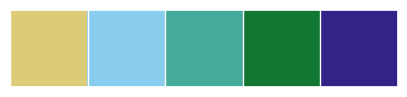

In [2]:
main_palette = ["#DDCC77", "#88CCEE", "#44AA99", "#117733", "#332288"]

sns.set_theme(
    style="whitegrid",       
    palette=main_palette,    
    font="sans-serif",       
    rc={"axes.titlesize": 14, "axes.labelsize": 12} 
)
sns.set_style('darkgrid', {'axes.facecolor': '#eeeeee'})

resize_plot = lambda: plt.gcf().set_size_inches(12, 5)
sns.palplot(sns.color_palette(main_palette))
plt.show()

<h3>2.1 Importando os datasets</h3>

Esses serãos os datasets usados durante toda a analise:

In [3]:
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
reviews = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
order_items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

items_grouped = order_items.groupby('order_id').agg({'shipping_limit_date': 'max'}).reset_index()

orders = (
    orders
    .merge(customers, on='customer_id')
    .merge(reviews, on='order_id')
    .merge(items_grouped, on='order_id')  
)

DROP_COLS = [
    'order_id',
    'customer_id',
    'customer_unique_id',
    'customer_zip_code_prefix',
    'customer_city',
    'review_id',
    'review_comment_title'
]

orders = orders.drop(columns=DROP_COLS).copy()

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['review_creation_date'] = pd.to_datetime(orders['review_creation_date'])
orders['review_answer_timestamp'] = pd.to_datetime(orders['review_answer_timestamp'])
orders['shipping_limit_date'] = pd.to_datetime(orders['shipping_limit_date'])

<h3>2.2 Criando classificadores para auxiliar na análise:</h3>

In [4]:
is_delivered = orders['order_status'] == 'delivered' 
delivery_status_diff = orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
delivery_time_status_diff = orders['order_delivered_customer_date'] - orders['order_approved_at']

# Definindo se a entrega do cliente foi atendida antes ou depois do prazo
orders.loc[is_delivered, 'delivery_status'] = np.where(
    (delivery_status_diff[is_delivered] > pd.Timedelta(days=1)),
    'Late',
    'On time'
)

# Definindo se o envio do cliente foi realizado antes ou depois do prazo
orders.loc[is_delivered, 'seller_sla_status'] = np.where(
    (orders.loc[is_delivered, 'order_delivered_carrier_date'] <= orders.loc[is_delivered, 'shipping_limit_date']),
    'On time',
    'Late'
)

# Definindo a velocidade com que a entrega foi realizada até o cliente 
orders.loc[is_delivered, 'delivery_time_status'] = np.select(
    [
        (delivery_time_status_diff[is_delivered].dt.days < delivery_time_status_diff[is_delivered].mean().days),
        (delivery_time_status_diff[is_delivered].dt.days == delivery_time_status_diff[is_delivered].mean().days)
    ],
    [
        'Fast',
        'Normal'
    ],
    default='Slow'
)

<h3>2.3 Organizando os dataframes:</h3>

In [5]:
df_review = orders[[
    'review_score',
    'review_comment_message',
    'review_creation_date',
    'review_answer_timestamp']]
status_df = orders[[
    'seller_sla_status',
    'delivery_status',
    'delivery_time_status']]
orders_df = orders[[
    'order_status',
    'customer_state',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_estimated_delivery_date',
    'order_delivered_carrier_date',
    'order_delivered_customer_date']]

<h2>3. Analisando avaliações que não possuem texto</h2>


<h3>3.1 Análise geral das avaliações</h3>


Conforme a relação abaixo, é possível notar uma grande quantidade de avaliações sem comentários. 

In [6]:
five_star = len(df_review[df_review['review_score'] == 5]) * 100 / len(df_review)
one_star = len(df_review[df_review['review_score'] == 1]) * 100 / len(df_review)
fisrt_dt = df_review['review_creation_date'].dt.date.min()
last_dt = df_review['review_creation_date'].dt.date.max()
with_text = df_review['review_comment_message'].notna().map({True:1, False:0}).sum() * 100 / len(df_review)
without_text = df_review['review_comment_message'].isna().map({True:1, False:0}).sum() * 100 / len(df_review)

print(f"Avaliações 5 estrelas: {five_star:.1f}%")
print(f"Avaliações 1 estrela: {one_star:.1f}%")
print(f"Data da primeira avaliação: {fisrt_dt}")
print(f"Data da última avaliação: {last_dt}")
print(f"Quantidade de avaliações com comentários: {with_text:.1f}%")
print(f"Quantidade de avaliações sem comentários: {without_text:.1f}%")

Avaliações 5 estrelas: 58.1%
Avaliações 1 estrela: 11.1%
Data da primeira avaliação: 2016-10-06
Data da última avaliação: 2018-08-31
Quantidade de avaliações com comentários: 41.1%
Quantidade de avaliações sem comentários: 58.9%


Gráfico direcionado para entender a distribuição das notas dos clientes:

Interessante observar que a quantidade de avaliações com apenas 1 estrela consegue superar as avaliações de 2 e 3 estrelas.

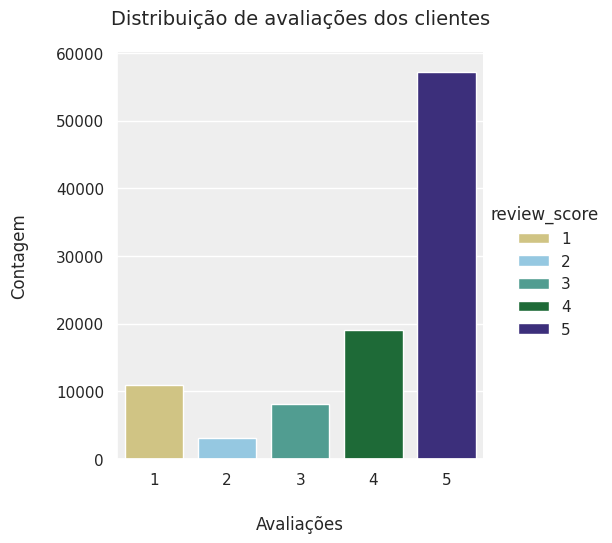

In [7]:
sns.catplot(data=df_review, x='review_score', kind='count', hue='review_score',palette=main_palette)
plt.title('Distribuição de avaliações dos clientes', pad=20)
plt.xlabel('Avaliações', labelpad=20)
plt.ylabel('Contagem', labelpad=20)
plt.show()

O mapa de calor abaixo é interessante pois demonstra o comportamento do cliente. Quando observamos as avaliações que não possuem comentários, notamos uma tendência proporcional a medida em que as avaliações são positivas, mas o contrário não ocorre. Quando olhamos para as avaliações que estão classificadas com comentários, podemos notar um pico muito grande nas avaliações com apenas 1 estrela, logo de cara podemos afirmar a necessidade do cliente em demonstrar seu feedback perante seu estado de chateação ou descepção. A grande questão é entender o que ocorre por trás desses feedbacks.

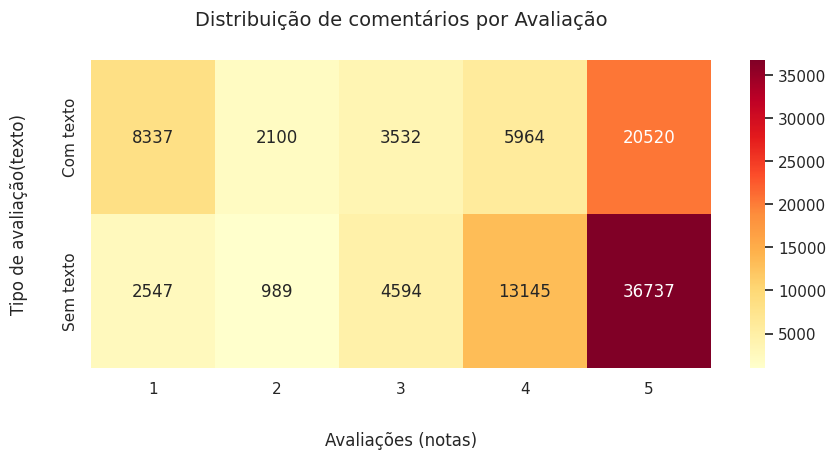

In [8]:
df_review_aux = df_review.copy()

df_review_aux['with_text'] = df_review['review_comment_message'].notna().map({True: 'Com texto', False: 'Sem texto'})

ct_rvw = pd.crosstab(df_review_aux['with_text'], df_review_aux['review_score'])

plt.figure(figsize=(10, 4))
sns.heatmap(ct_rvw, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd')
plt.title('Distribuição de comentários por Avaliação', pad=25)
plt.xlabel('Avaliações (notas)', labelpad=25)
plt.ylabel('Tipo de avaliação(texto)', labelpad=25)
plt.show()

O gráfico de barras abaixo comprova a minha afirmação, onde o comprimento médio dos textos de avaliações dos clientes aumentam de forma proporcional a medida em que as notas são menores.

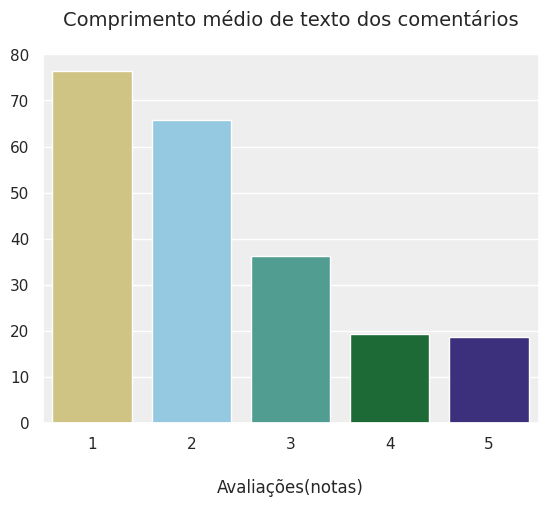

In [9]:
df_review_aux = df_review.copy()

df_review_aux['comment_length'] = ( df_review_aux['review_comment_message'].fillna('').str.len())
avg_length = (df_review_aux.groupby('review_score')['comment_length'].mean())

sns.barplot(
    x=avg_length.index,
    y=avg_length.values,
    hue=avg_length.index,
    legend=False,
    palette=main_palette[:len(avg_length)]
)

plt.xlabel('Avaliações(notas)', labelpad=20)
plt.title('Comprimento médio de texto dos comentários', pad=20)

plt.show()

<h3>3.2 Analise aproximativa: métricas de envio e status de entregas</h3>

Como observado no mapa de calor, a relação entre avaliações com e sem texto e conseguimos definir um possível comportamento do cliente perante a sua situação (sendo boa ou ruim). Olhando para avaliações sem texto, não há um parâmetro exato que demostre o feedback direto do cliente, servido quase como um feedback fantasma. A análise abaixo visa entender os possíveis motivos pelos quais os clientes estariam avaliando de forma negativa.

O gráfico abaixo mostra a relação entre o tempo que levou a entrega com as avaliações abaixo de 4: 

- Fast: Entrega rápida,
- Normal: Entrega normal,
- Slow: Entrega lenta.
  

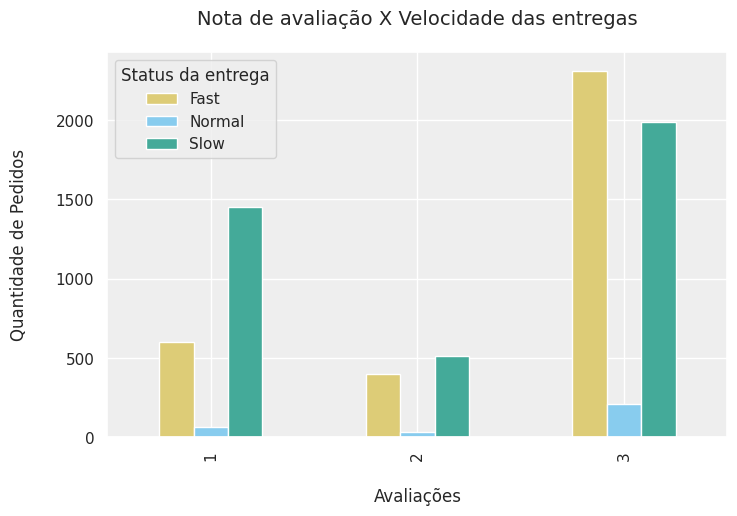

In [12]:
LowRev_na = df_review[(df_review['review_comment_message'].isna()) & (df_review['review_score'] < 4)]
ct_sts = pd.crosstab(status_df['delivery_time_status'],orders_df['order_status'])
ct_rvw = pd.crosstab(LowRev_na['review_score'], status_df['delivery_time_status'])


ct_rvw.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Nota de avaliação X Velocidade das entregas', pad=20)
plt.xlabel('Avaliações', labelpad=20)
plt.ylabel('Quantidade de Pedidos', labelpad=20)
plt.legend(title='Status da entrega')
plt.show()

O gráfico abaixo mostra a relação entre as avaliações e o SLA (tempo padrão de envio) do vendedor:

* On time: Produto postado dentro do tempo padrão.

* Late: Produto postado fora do tempo padrão.

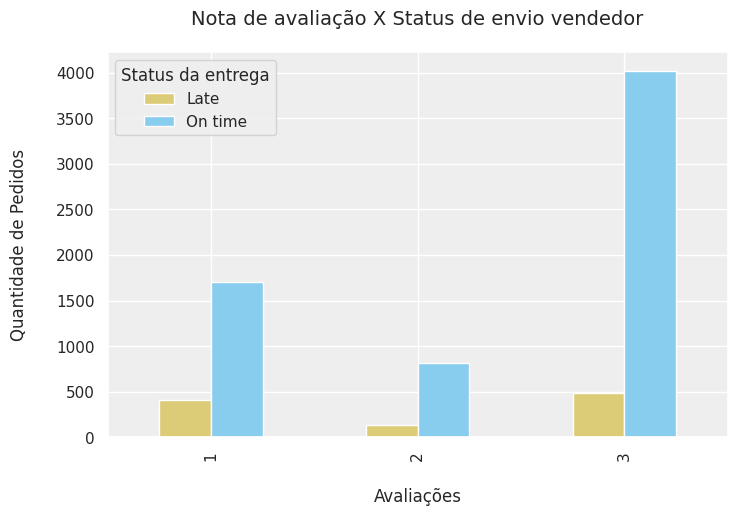

In [13]:
LowRev_na = df_review[(df_review['review_comment_message'].isna()) & (df_review['review_score'] < 4)]
ct_sts_sla = pd.crosstab(status_df['seller_sla_status'],orders_df['order_status'])
ct_rvw_sla = pd.crosstab(LowRev_na['review_score'], status_df['seller_sla_status'])


ct_rvw_sla.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Nota de avaliação X Status de envio vendedor', pad=20)
plt.xlabel('Avaliações',labelpad=20)
plt.ylabel('Quantidade de Pedidos', labelpad=20)
plt.legend(title='Status da entrega')
plt.show()

<h2>4. Analisando avaliações que possuem texto</h2>


Conforme vimos no mapa de calor, a quantidade de avaliações negativas com comentários é muito significativa, um feedback direto da fustração do cliente e com o que ele está frustado. Com a ideia de tentar entender essa frustação, veio em mente o Spacy como uma ferramenta ideal para tentar enteder os feedbacks e classificá-los. Spacy é uma blibioteca de NLP, que significa *Natural Language Processing* ou Processamento de Linguagem Natural, que visa a utilização do processamento para entender a linguagem local e seus contexto. Essa parte do notebook será focada na configuração e aplicação do Spacy, de forma amostral, nas avaliações dos clientes com texto para que seja possível entender o que está ocorrendo.

<h3>4.1 Preparação do ambiente para aplicação do Spacy</h3>

Estrutura do Pipeline de Processamento (NLP)
Abaixo, apresento o pipeline desenvolvido para o treinamento e aplicação do modelo spaCy. Este processo foi estruturado em três etapas fundamentais para garantir a qualidade da análise:

* Preparação e Padronização: Os dados brutos passam por um processo de conversão para o formato DocBin. Esse formato é otimizado para o spaCy, garantindo que o modelo aprenda com as marcações de forma eficiente e sem perda de contexto semântico.

* Treinamento Estatístico: Diferente de uma busca simples por palavras-chave, o modelo aprende os padrões probabilísticos das reclamações. A configuração utilizada permite que o sistema identifique se um comentário pertence a "Produto" ou "Logística" baseado no contexto da frase.

* Inferência e Confiabilidade: Na fase de aplicação, o modelo atua como um classificador de alta precisão. O pipeline foi configurado para que apenas classificações com alta probabilidade sejam consideradas, garantindo que os resultados extraídos da amostra sejam robustos e confiáveis para a tomada de decisão.

In [16]:

class SpacyModelPipeline:
    def __init__(self, base_dir="/kaggle/working"):
        # Define os diretórios de trabalho 
        self.base = Path(base_dir)
        self.data_dir = self.base / "data"
        self.output_dir = self.base / "output"
        self.data_dir.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def prepare_data(self, df):
        # Divide os dados em treino e validação (80/20) para o aprendizado
        df_train, df_valid = train_test_split(df, test_size=0.2, random_state=42)
        nlp = spacy.blank("pt") 
        
        def _converter(data_frame, file_name):
            # Converte o dataframe para o formato binário otimizado do spaCy (DocBin)
            final_path = self.data_dir / file_name
            db = DocBin()
            for _, row in data_frame.iterrows():
                doc = nlp.make_doc(str(row['review_text']))
                doc.cats = {
                    "product": bool(row['PROD']),
                    "logistics": bool(row['LOG'])
                }
                db.add(doc)
            db.to_disk(final_path)
            print(f"Arquivo gerado: {final_path}")
        
        _converter(df_train, "train.spacy")
        _converter(df_valid, "valid.spacy")

    def train(self, config_path):
        # Chama o comando CLI do spaCy para iniciar o treinamento do modelo
        cmd = [
            "python", "-m", "spacy", "train", config_path,
            "--output", str(self.output_dir),
            "--paths.train", str(self.data_dir / "train.spacy"),
            "--paths.dev", str(self.data_dir / "valid.spacy"),
        ]
        subprocess.run(cmd, check=True)

    def apply(self, df, column_name='review_comment_message'):
        # Carrega o melhor modelo treinado a partir da pasta output
        nlp = spacy.load(self.output_dir / "model-best")
        
        texts = df[column_name].astype(str).tolist()
        pred_prod, pred_log = [], []
        
        # Processa em lote para maior performance na extração das categorias
        for doc in nlp.pipe(texts, batch_size=256):
            # Aplica o threshold de 0.5 para decisão binária das categorias
            pred_prod.append(1.0 if doc.cats.get("product", 0) >= 0.5 else 0.0)
            pred_log.append(1.0 if doc.cats.get("logistics", 0) >= 0.5 else 0.0)
        
        # Retorna o dataframe original acrescido das novas colunas de predição
        df = df.copy()
        df['log_PROD'] = pred_prod
        df['log_LOGIS'] = pred_log
        return df

In [17]:
df_review_notna = df_review[df_review['review_comment_message'].notna()]

PATH_CSV_TRAIN = "/kaggle/input/models/marcoantoniocosta/model-traning-spacy/tensorflow2/default/1/model_traning/model_ml.csv"
CONFIG_FILE = "/kaggle/input/models/marcoantoniocosta/model-nlp/tensorflow2/default/1/spacy_model/model-best/config.cfg"
pipeline = SpacyModelPipeline()

# Carrega o dataset original de treino
df_raw = pd.read_csv(PATH_CSV_TRAIN)
# Prepara os arquivos .spacy (train.spacy e valid.spacy)
pipeline.prepare_data(df_raw)
# Executa o comando de treino do spaCy
pipeline.train(CONFIG_FILE)
# Classifica o dataframe de trabalho usando o modelo treinado
df_nlp = pipeline.apply(df_review_notna, column_name='review_comment_message')

Arquivo gerado: /kaggle/working/data/train.spacy
Arquivo gerado: /kaggle/working/data/valid.spacy
ℹ Saving to output directory: /kaggle/working/output
ℹ Using CPU

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'textcat_multilabel']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS TEXTC...  CATS_SCORE  SCORE 
---  ------  ------------  -------------  ----------  ------
  0       0          0.00           0.25       86.73    0.87
 40     200          0.00          10.77       98.92    0.99
 80     400          0.00           0.36       98.98    0.99
120     600          0.00           0.13       99.10    0.99
160     800          0.00           0.08       99.10    0.99
200    1000          0.00           0.05       99.10    0.99
240    1200          0.00           0.03       99.05    0.99
280    1400          0.00        

Ao analisar o desempenho do modelo (tabela abaixo), é possível observar alguns pontos:

* Precisão de 100% (Especificidade): O modelo foi configurado para ser altamente rigoroso. Isso significa que, quando ele identifica uma categoria, a chance de erro é praticamente nula.

* Recall de 88% (Produto) e 50% (Logística): O recall mede a capacidade do modelo de encontrar todas as instâncias existentes de uma categoria.

* Um recall de 88% para Produto mostra que o modelo reconhece a maioria dos padrões desse grupo.

* Um recall de 50% para Logística indica que o modelo está sendo mais seletivo. Ele só categoriza como "Logística" as mensagens que apresentam padrões muito claros e explícitos. Ruídos nas mensagens acabam sendo descartadas pelo sistema, resultando nessa cobertura menor.

In [18]:
meta_path = Path("/kaggle/working/output/model-best/meta.json")

with open(meta_path, "r") as f:
    meta = json.load(f)
    
metrics = (
    pd.DataFrame(meta['performance']['cats_f_per_type'])
    .T
    .rename(
        index={
            'logistics': 'Logistics',
            'product': 'Product'
        },
        columns={
            'p': 'Precision (%)',
            'r': 'Recall (%)',
            'f': 'F1-Score (%)'
        }
    )
    .mul(100)
    .round(2)
)

print(metrics)

           Precision (%)  Recall (%)  F1-Score (%)
Product            100.0        88.0         93.62
Logistics          100.0        50.0         66.67


Abaixo podemos ver o resultado (amostra) do modelo e suas classificações, logisitca e produto:

In [19]:
df_nlpLowRev = df_nlp[df_nlp['review_score'] < 4].drop_duplicates()
df_nlpLowRev

,review_score,review_comment_message,review_creation_date,review_answer_timestamp,log_PROD,log_LOGIS
6,2,fiquei triste por n ter me atendido.,2017-05-13,2017-05-13 20:25:42,0.0,0.0
10,1,Aguardando retorno da loja,2017-05-30,2017-05-30 23:13:47,0.0,0.0
19,2,os correios estäo em greve... näo recebi nenhu...,2017-10-01,2017-10-01 17:55:21,0.0,0.0
24,2,Demora muito entregar. Já passou o prazo e ain...,2018-03-16,2018-03-20 23:10:58,0.0,1.0
25,1,Até o momento não recebi o produto Protetor De...,2018-06-17,2018-06-20 11:38:22,0.0,0.0
...,...,...,...,...,...,...
98427,1,Não gostei imaginei que era uma cortina de tec...,2018-02-16,2018-02-19 09:33:09,0.0,0.0
98447,1,nao recebi o produto que ja paguei ! nao recom...,2017-11-03,2017-11-06 18:50:22,0.0,0.0
98449,1,"Prateleiras com cantos vivo, colunas nao encai...",2018-04-11,2018-04-11 12:41:03,0.0,0.0
98456,1,"Ele não é um mini cajon, é um shaker, ou seja,...",2018-01-19,2018-01-21 02:51:39,0.0,0.0


In [20]:
nlp_cross_log = pd.crosstab(df_nlpLowRev['log_LOGIS'],status_df['delivery_time_status'])
nlp_cross_prod = pd.crosstab(df_nlpLowRev['log_PROD'], status_df['delivery_time_status'])

df_nlpLowRev[df_nlpLowRev['log_LOGIS'] == 1][['review_comment_message']].sample(5).rename(columns={'review_comment_message':'Review_Log'})

,Review_Log
2686,Não foi entregue na minha residencia tive que ...
3858,o pedido nao foi entregue
8943,nao recebi o produto acredito ser problema dos...
89677,No site informa que o produto foi entregue em ...
62068,Realizei a compra de 3 unidades.Mas qual foi m...


In [21]:
df_nlpLowRev[df_nlpLowRev['log_PROD'] == 1][['review_comment_message']].sample(5).rename(columns={'review_comment_message':'Review_Prod'})

,Review_Prod
9805,O produto não apresenta boa qualidade e veio f...
40722,O produto nao corresponde ao modelo
65718,"Demorou um pouco, mas chegou."
15346,Não cumpriu com o prometido
69582,A pulseira do relógio veio com duas manchas.


<h3>4.2 Analise aproximativa: utilizando o modelo NLP para comparativo entre métricas </h3>

Cruzamento entre o data-frame de status de entrega com os resultados do modelo:

In [22]:
nlp_cross_log_dld = pd.crosstab(df_nlpLowRev['log_LOGIS'],status_df['delivery_time_status'])
nlp_cross_prod_dld = pd.crosstab(df_nlpLowRev['log_PROD'], status_df['delivery_time_status'])

nlp_cross_dld = pd.DataFrame({
    'Log': nlp_cross_log_dld.loc[1],
    'Prod': nlp_cross_prod_dld.loc[1]
})

nlp_cross_dld

,Log,Prod
delivery_time_status,,
Fast,837,1001
Normal,71,80
Slow,1335,790


É notória a forte correlação entre entregas lentas e o volume de reclamações com texto, que superam a soma das categorias rápida e normal juntas, evidenciando o peso dos problemas logísticos. Por outro lado, ao analisarmos as entregas rápidas e normais, o cenário muda: com a eficiência do transporte, o foco da insatisfação do cliente passa a ser o produto.

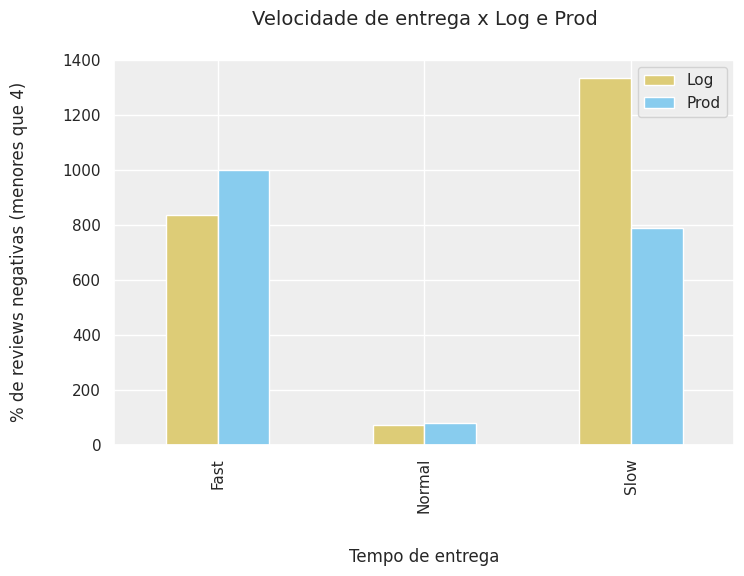

In [23]:
nlp_cross_dld.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Velocidade de entrega x Log e Prod', pad=25)
plt.ylabel('% de reviews negativas (menores que 4)', labelpad=25)
plt.xlabel('Tempo de entrega', labelpad=25)
width=1.0
plt.show()

Cruzamento entre o data-frame de status de envio do vendedor (SLA) com os resultados do modelo:

In [24]:
nlp_log_sla = pd.crosstab(df_nlpLowRev['log_LOGIS'],status_df['seller_sla_status'])
nlp_prod_sla = pd.crosstab(df_nlpLowRev['log_PROD'], status_df['seller_sla_status'])

nlp_cross_sla = pd.DataFrame({
    'Log': nlp_log_sla.loc[1],
    'Prod': nlp_prod_sla.loc[1]
})

nlp_cross_sla

,Log,Prod
seller_sla_status,,
Late,385,248
On time,1858,1623


O gráfico abaixo ilustra a relação entre o SLA de postagem do vendedor e as categorias extraídas pelo modelo de NLP. Notavelmente, os resultados convergem perfeitamente com o comportamento observado na análise anterior das avaliações 'fantasmas' (sem comentários).

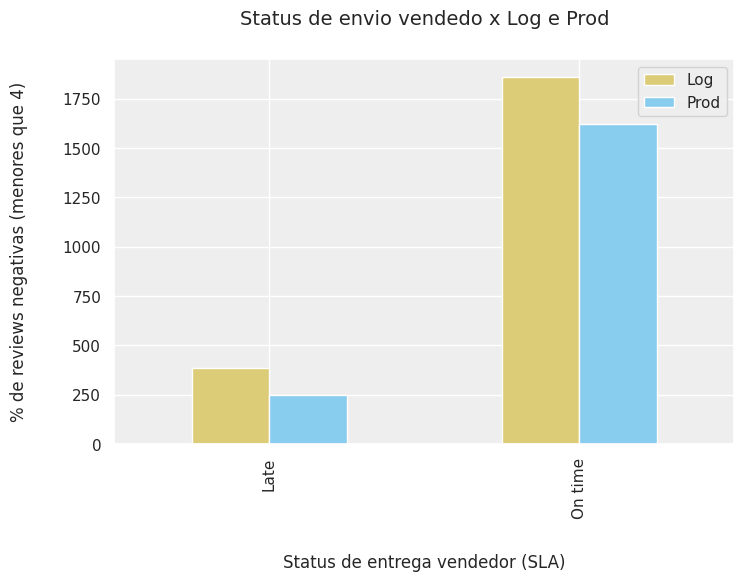

In [25]:
nlp_cross_sla = nlp_cross_sla.copy()
nlp_cross_sla.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Status de envio vendedo x Log e Prod', pad=25)
plt.ylabel('% de reviews negativas (menores que 4)', labelpad=25)
plt.xlabel('Status de entrega vendedor (SLA)', labelpad=25)
width=1.0
plt.show()

<h3>4.3 Analise comparativa: correlação entre os gráficos e métricas com e sem texto</h3>

Como observado ao longo deste notebook, o gráfico da esquerda foi desenvolvido para entender o comportamento do consumidor nas avaliações 'fantasmas' (sem texto), utilizando uma abordagem analítica baseada em aproximações e tabelas de contingência (status de velocidade vs. notas de avaliação).

Já o gráfico da direita funciona como uma extensão direta dessa investigação: usando o modelo de NLP para extrair padrões dos comentários escritos, servindo como uma validação qualitativa das métricas operacionais criadas anteriormente.

Ao analisar ambos os gráficos lado a lado, o diagnóstico de causa raiz torna-se evidente e incontroverso. Ambas as abordagens apontam para o mesmo resultado: a ineficiência da malha logística é o principal motivo de detração das notas, superando massivamente as queixas relacionadas à qualidade do produto ou a atrasos na postagem por parte do vendedor.

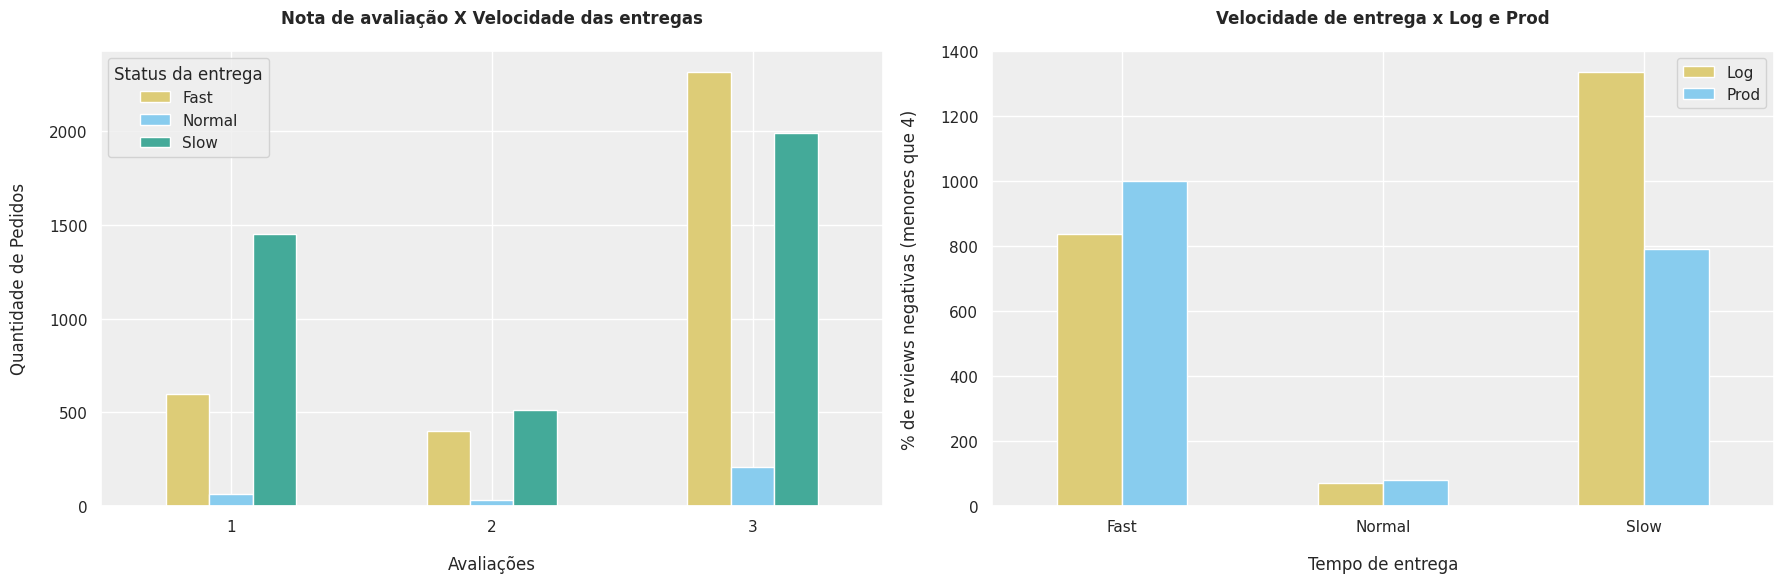

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ct_rvw.plot(
    kind='bar',
    ax=axes[0]  
)
axes[0].set_title('Nota de avaliação X Velocidade das entregas', pad=20, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avaliações', labelpad=15)
axes[0].set_ylabel('Quantidade de Pedidos', labelpad=15)
axes[0].legend(title='Status da entrega')
axes[0].tick_params(axis='x', rotation=0) 

nlp_cross_dld.plot(
    kind='bar',
    ax=axes[1]  
)
axes[1].set_title('Velocidade de entrega x Log e Prod', pad=20, fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tempo de entrega', labelpad=15)
axes[1].set_ylabel('% de reviews negativas (menores que 4)', labelpad=15)
axes[1].tick_params(axis='x', rotation=0) 
plt.tight_layout()
plt.show()

Dando continuidade na analise acima, ao analisarmos os gráficos de entrega: fica evidente que o volume crítico de detração está diretamente atrelado a falhas logísticas, ocorrendo justamente nos cenários onde o vendedor cumpriu rigorosamente o seu prazo de postagem (SLA positivo).

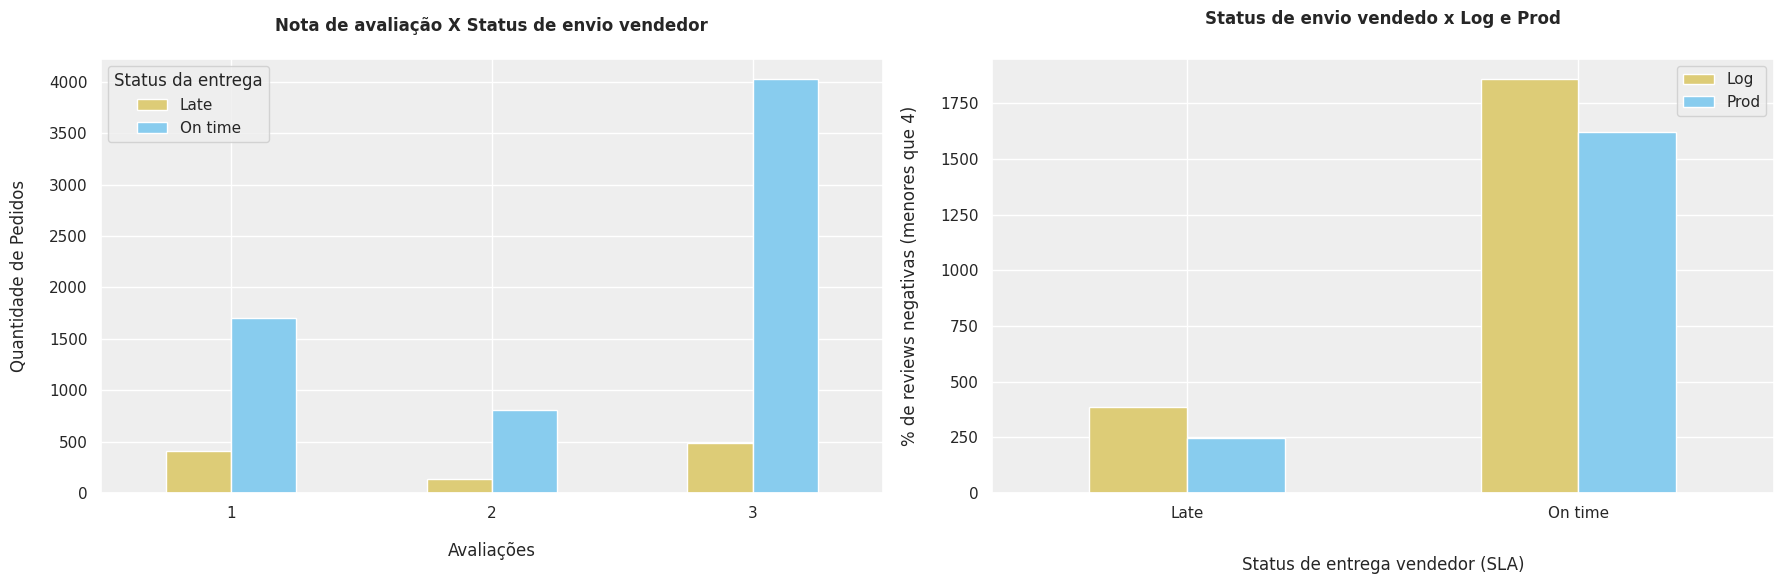

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ct_rvw_sla.plot(
    kind='bar',
    ax=axes[0]  
)
axes[0].set_title('Nota de avaliação X Status de envio vendedor', pad=20, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avaliações', labelpad=15)
axes[0].set_ylabel('Quantidade de Pedidos', labelpad=15)
axes[0].legend(title='Status da entrega')
axes[0].tick_params(axis='x', rotation=0) 

nlp_cross_sla.plot(
    kind='bar',
    ax=axes[1]  
)
axes[1].set_title('Status de envio vendedo x Log e Prod', pad=25, fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status de entrega vendedor (SLA)', labelpad=25)
axes[1].set_ylabel('% de reviews negativas (menores que 4)', labelpad=15)
axes[1].tick_params(axis='x', rotation=0) 
plt.tight_layout()
plt.show()




<h2>5. Conclusão</h2>


Ao longo deste projeto, propusemos uma investigação aprofundada sobre a causa raiz das avaliações negativas no e-commerce. Para isso, foi fundamental segmentar a análise em dois ecossistemas: as avaliações com comentários e as avaliações 'fantasmas' (sem texto). No grupo de avaliações sem texto, utilizamos métricas operacionais criadas a partir de atributos (como SLA e percepção de velocidade) para correlacionar quantitativamente o comportamento das notas baixas com os tempos das entregas.

Por outro lado, para a base de avaliações com texto, foi desenvolvido um modelo de NLP (Processamento de Linguagem Natural) com a blibioteca Spacy, com intuíto de extrair de forma precisa os dados qualitativos e as reais dores manifestadas pelos consumidores.

Como resultado, ambas as abordagens convergiram para o mesmo diagnóstico: a ineficiência e os gargalos da malha logística são os principais vetores de detração das notas, superando massivamente as queixas relacionadas aos lojistas ou à qualidade dos produtos.

Como recomendação: Uma implementação de um score de performance logística,um indicador interno para ranquear as transportadoras. Transportadoras com altos índices de atraso ou entregas categorizadas como Slow perderiam volume de pedidos para parceiros mais eficientes.